# Strava API thingy

- See the [Getting Started Docs](https://developers.strava.com/docs/getting-started/)
- You can get data on yourself without authentication for testing purposes.
- See also the [Strava API v3 reference docs](https://developers.strava.com/docs/reference/)

See [README.md](README.md) for more information about what I want to achive here.


## Contents

- <a href="#Authentication">Authentication</a>
- <a href="#Basic-API-Requests">Basic API Requests</a>
- <a href="#Pandas-Data-Frames">Pandas Data Frames</a>
- <a href="#Data-Streams">Data Streams</a> -- i.e. watts, cadence, heart rate, time, etc.

----

In [ ]:
import os
import requests
import pandas as pd

client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")
access_token = os.environ.get("ACCESS_TOKEN")

client_id, client_secret, access_token

In [ ]:
class StravaClient:
    BASE_URL = "https://www.strava.com/api/v3"

    def __init__(self, client_id, client_secret, access_token=None, refresh_token=None):
        self.client_id = client_id
        self.client_secret = client_secret
        self.access_token = access_token
        self.refresh_token = refresh_token

    @property
    def _headers(self):
        return {"Authorization": f"Bearer {self.access_token}"}

    def set_token_from_response(self, data: dict):
        self.access_token = data["access_token"]
        self.refresh_token = data.get("refresh_token")

    def exchange_code(self, code: str) -> dict:
        """Exchange authorization CODE for tokens (first-time OAuth flow)."""
        url = "https://www.strava.com/oauth/token"
        payload = {
            "client_id": self.client_id,
            "client_secret": self.client_secret,
            "code": code,
            "grant_type": "authorization_code",
        }
        resp = requests.post(url, payload)
        resp.raise_for_status()
        self.set_token_from_response(resp.json())
        return resp.json()

    def refresh_access_token(self) -> dict:
        """Use refresh_token to get a new access_token (call when token expires)."""
        url = "https://www.strava.com/oauth/token"
        payload = {
            "client_id": self.client_id,
            "client_secret": self.client_secret,
            "grant_type": "refresh_token",
            "refresh_token": self.refresh_token,
        }
        resp = requests.post(url, payload)
        resp.raise_for_status()
        self.set_token_from_response(resp.json())
        return resp.json()

    def get_athlete(self) -> dict:
        """Fetch the authenticated athlete's profile."""
        resp = requests.get(f"{self.BASE_URL}/athlete", headers=self._headers)
        resp.raise_for_status()
        return resp.json()

    def get_activities(self, per_page: int = 100) -> list:
        """Fetch ALL activities using pagination (loops until empty page)."""
        all_activities = []
        page = 1
        while True:
            resp = requests.get(
                f"{self.BASE_URL}/athlete/activities",
                headers=self._headers,
                params={"per_page": per_page, "page": page},
            )
            resp.raise_for_status()
            batch = resp.json()
            if not batch:
                break
            all_activities.extend(batch)
            page += 1
        return all_activities

    def get_activity_streams(self, activity_id: int, stream_types: list) -> list:
        """Fetch data streams for a single activity."""
        resp = requests.get(
            f"{self.BASE_URL}/activities/{activity_id}/streams",
            headers=self._headers,
            params={"keys": ",".join(stream_types), "key_by_type": ""},
        )
        resp.raise_for_status()
        return resp.json()

---- 

## Authentication

In [22]:
# Generate URL hack to get short-lived token, open in new browser, then
# Capture the CODE from the redirect-url & copy below.
scopes = "read,read_all,activity:read,activity:read_all"
allow_url = (
    f"http://www.strava.com/oauth/authorize?client_id={client_id}&response_type=code&redirect_uri="
    f"http://localhost/exchange_token&approval_prompt=force&scope={scopes}"
)
print(allow_url)

http://www.strava.com/oauth/authorize?client_id=102704&response_type=code&redirect_uri=http://localhost/exchange_token&approval_prompt=force&scope=read,read_all,activity:read,activity:read_all


In [ ]:
# Instantiate the client (uses env-loaded credentials)
client = StravaClient(client_id, client_secret, access_token=access_token)

# --- Only if your token is expired and you have a fresh CODE from the browser:
# CODE = "paste-code-here"
# data = client.exchange_code(CODE)
# print(data)

print(f"Client ready. Token: {client.access_token[:10]}...")

In [ ]:
# --- Token Refresh (run this if you get 401 errors — tokens expire after 6 hours)
# The refresh_token from the exchange_code response is stored in client.refresh_token.
# Uncomment and run to get a fresh access_token without going through the browser flow.

# data = client.refresh_access_token()
# print(f"New access_token expires at: {data['expires_at']}")

---- 

## Basic API Requests

In [ ]:
# Basic Requests
athlete = client.get_athlete()
athlete

In [ ]:
# Fetches ALL activities across all pages (may take several seconds for large accounts)
activities = client.get_activities()
print(f"Found {len(activities)} total activities.")

In [26]:
# Activity fields
sorted(activities[0].keys())

['achievement_count',
 'athlete',
 'athlete_count',
 'average_cadence',
 'average_heartrate',
 'average_speed',
 'average_watts',
 'comment_count',
 'commute',
 'device_watts',
 'display_hide_heartrate_option',
 'distance',
 'elapsed_time',
 'elev_high',
 'elev_low',
 'end_latlng',
 'external_id',
 'flagged',
 'from_accepted_tag',
 'gear_id',
 'has_heartrate',
 'has_kudoed',
 'heartrate_opt_out',
 'id',
 'kilojoules',
 'kudos_count',
 'location_city',
 'location_country',
 'location_state',
 'manual',
 'map',
 'max_heartrate',
 'max_speed',
 'max_watts',
 'moving_time',
 'name',
 'photo_count',
 'pr_count',
 'private',
 'resource_state',
 'sport_type',
 'start_date',
 'start_date_local',
 'start_latlng',
 'suffer_score',
 'timezone',
 'total_elevation_gain',
 'total_photo_count',
 'trainer',
 'type',
 'upload_id',
 'upload_id_str',
 'utc_offset',
 'visibility',
 'weighted_average_watts']

In [29]:
for activity in activities:
    dt = activity["start_date_local"].split("T")[0]
    print(f"[{activity['id']}|{dt}] {activity['name']}")

[10804601892|2024-02-20] Zwift - ⏱ - House of Pain #21 - Gotta Push to Reach Those Goals - Z5 Round 2! in Makuri Islands
[10796538593|2024-02-19] Just a Monday afternoon neighborhood circuit
[10790951407|2024-02-18] Zwift - ⏱ - House of Pain #20 - Pyramids and Ramps with a Sport Specific Finish - Grab that Fan it’s going to be a ♨️ one. in Makuri Islands
[10783923127|2024-02-17] MSGC Bentonia
[10770651997|2024-02-15] Afternoon Ride
[10757552547|2024-02-13] Zwift - ⏱ - House of Pain #19 - Forget Zone 4…Let’s Play in ZONE 5… in Makuri Islands
[10750314756|2024-02-12] Zwift - Neon Flats in Makuri Islands
[10744031009|2024-02-11] Zwift - Loch Loop in Scotland
[10736363606|2024-02-10] HoP#18 -DNF
[10724998291|2024-02-08] Tour de Bartlett
[10718732821|2024-02-07] Hump Day!
[10721337847|2024-02-07] Afternoon Weight Training
[10711798685|2024-02-06] Zwift - ⏱ - House of Pain #17 - If It Was Easy, Everyone Would Do It. 4 x 10 Hammertime in Makuri Islands
[10704471361|2024-02-05] Maiden Voyage.


---- 

## Pandas Data Frames

In [ ]:
def extract(data: dict, keys: list) -> dict:
    """Extract a dict containing the given keys from an input dict"""
    # See: https://stackoverflow.com/a/74383892/182778
    return {key: val for key in keys if (val := data.get(key))}

KEYS = [
    "name",
    "id",
    "resource_state",  # 2 is cycling
    "start_date",
    "moving_time",
    'average_cadence',
    'average_heartrate',
    'average_speed',
    'average_watts',
    'max_heartrate',
    'max_speed',
    'max_watts',
    'weighted_average_watts',
    'suffer_score',
    'kilojoules',
    'distance',
    'elapsed_time',
    'elev_high',
    'elev_low',
]


df = pd.DataFrame([extract(a, KEYS) for a in activities], columns=KEYS)
df = df.set_index("start_date")
df.index = pd.to_datetime(df.index, utc=True)
df.head()

<Axes: xlabel='start_date'>

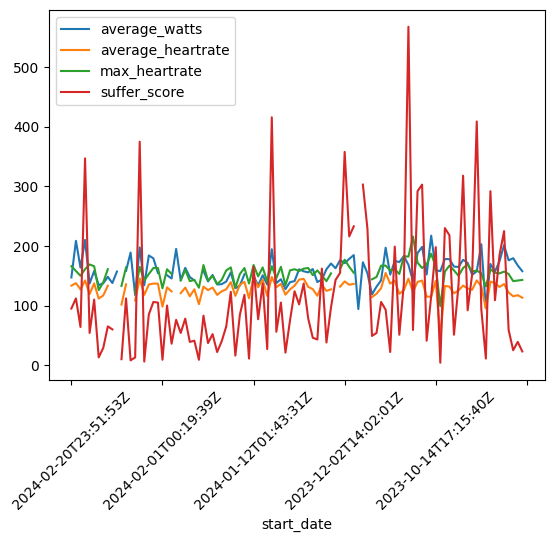

In [93]:
df[["average_watts","average_heartrate","max_heartrate","suffer_score"]].plot(rot=45)

<Axes: xlabel='start_date'>

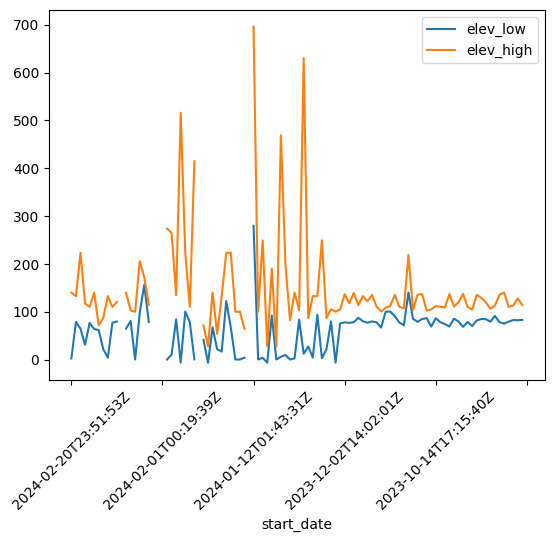

In [94]:
df[['elev_low', 'elev_high']].plot(rot=45)

<Axes: xlabel='start_date'>

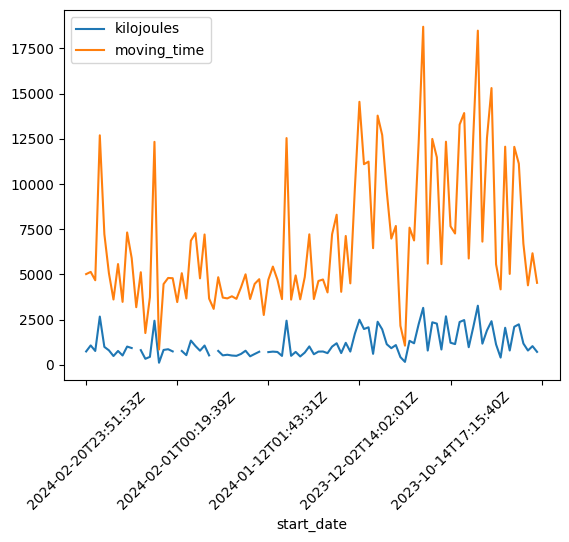

In [95]:
df[['kilojoules', 'moving_time']].plot(rot=45)

<Axes: xlabel='start_date'>

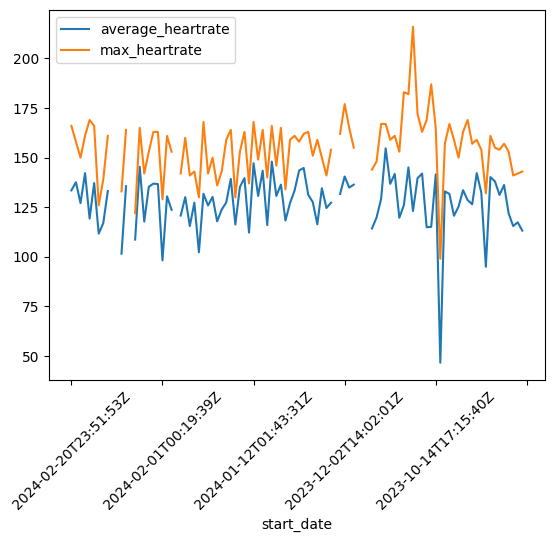

In [96]:
df[["average_heartrate","max_heartrate"]].plot(rot=45)


----

## Data Streams

https://developers.strava.com/docs/reference/#api-Streams-getActivityStreams

> Returns the given activity's streams. Requires activity:read scope. Requires activity:read_all scope for Only Me activities.


See also: Strava Docs on `StreamSet` -- types of data available in streams.
https://developers.strava.com/docs/reference/#api-models-StreamSet

In [ ]:
# Use the most recent activity, or pin a specific one below
activity_id = activities[0]["id"]
# activity_id = 10804601892

STREAM_TYPES = ["time", "distance", "heartrate", "cadence", "watts"]
streams = client.get_activity_streams(activity_id, STREAM_TYPES)
print(f"Found {len(streams)} streams for activity {activity_id}.")

# --- Stream object keys
for i, stream in enumerate(streams):
    stype = stream["type"]
    print(f"Stream {i}: {stype}: {', '.join(stream.keys())}")

In [56]:
for i, stream in enumerate(streams):
    print(stream['type'], stream['series_type'], stream['original_size'], stream['resolution'])

watts distance 5017 high
cadence distance 5017 high
distance distance 5017 high
heartrate distance 5017 high
time distance 5017 high


In [80]:
# Create a Data Frame with all the data streams
ds = {s['type']: pd.Series(s['data']) for s in streams}
df = pd.DataFrame(ds).set_index('time')
df.head()

,watts,cadence,distance,heartrate
time,,,,
0,111,56,2.1,67
1,93,58,4.3,68
2,79,62,7.2,71
3,69,67,10.5,71
4,79,69,14.3,73


<Axes: xlabel='time'>

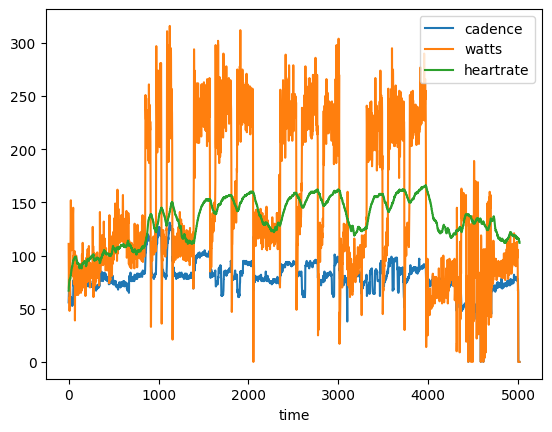

In [86]:
df[["cadence", "watts", "heartrate"]].plot()